<a href="https://colab.research.google.com/github/Hritik246/Hritik246/blob/main/PoC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Once your Google Drive is mounted, you can access files in your Drive using the path `/content/drive/My Drive/your_folder_name/your_file_name`.

In [ ]:

from google.colab import files
uploaded = files.upload()





Saving Data.csv to Data.csv


In [ ]:

import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['Data.csv']))
print(df)





     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1    0.745071    0.536681    840.557234   6.732863e-17   
1              2   -0.207396    0.841177    940.062498   7.529901e-17   
2              3    0.971533    1.624577   1000.524370   8.014200e-17   
3              4    2.284545    1.580703   1004.698059   8.047631e-17   
4              5   -0.351230   -2.066504    954.993453   7.649498e-17   
..           ...         ...         ...           ...            ...   
195          196    0.577976   -0.703763    948.998360   7.601477e-17   
196          197   -1.325786   -2.569702    973.012506   7.793830e-17   
197          198    0.230588    2.030809           NaN   7.226010e-17   
198          199    0.087313   -0.171810    955.570674   7.654121e-17   
199          200   -1.714455    1.856724   1037.730049   8.312218e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        843.877093              0.044244           2.726625

In [ ]:
df.shape


(200, 8)

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3- Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[((df < lower_bound) | (df > upper_bound)).any(axis=1)]

print("Potential outliers based on IQR:")
display(outliers)

Potential outliers based on IQR:


,Particle_ID,Position_X,Position_Y,Velocity_mps,Energy_Joules,Lens_Voltage_V,Spherical_Aberration,Trajectory_Spread
2,3,0.971533,1.624577,1000.524370,8.014200e-17,1580.054805,0.075601,6.726962
9,10,0.813840,5.779097,1051.443883,8.422066e-17,1862.675842,0.068124,48.221797
11,12,-0.698595,1.703348,887.535791,7.109162e-17,10000.000000,0.044375,23.338379
62,63,-1.659502,-4.861901,930.027449,7.449520e-17,1370.882525,0.072989,31.999631
74,75,-3.929618,-1.472263,1164.496771,9.327619e-17,600.614716,0.049653,24.090360
78,79,0.137641,0.104703,1307.888081,1.047618e-16,807.709461,0.059843,0.553832
113,114,3.694863,1.220264,909.243634,7.283042e-17,864.758286,0.042691,23.462995
123,124,-2.102777,3.138581,1057.059867,8.467050e-17,628.262796,0.060442,54.490323
125,126,3.285683,-1.821283,819.511790,6.564289e-17,539.798306,0.068467,51.499705
152,153,-1.020037,1.286489,1116.778206,8.945393e-17,10000.000000,0.052494,23.935333


In [ ]:
df.isnull().sum()



,0
Particle_ID,0
Position_X,0
Position_Y,0
Velocity_mps,0
Energy_Joules,0
Lens_Voltage_V,0
Spherical_Aberration,0
Trajectory_Spread,0


In [ ]:
df["Velocity_mps"] = df["Velocity_mps"].fillna(df["Velocity_mps"].median())


In [ ]:
print(df)

     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1    0.745071    0.536681    840.557234   6.732863e-17   
1              2   -0.207396    0.841177    940.062498   7.529901e-17   
2              3    0.971533    1.624577   1000.524370   8.014200e-17   
3              4    2.284545    1.580703   1004.698059   8.047631e-17   
4              5   -0.351230   -2.066504    954.993453   7.649498e-17   
..           ...         ...         ...           ...            ...   
195          196    0.577976   -0.703763    948.998360   7.601477e-17   
196          197   -1.325786   -2.569702    973.012506   7.793830e-17   
197          198    0.230588    2.030809    993.392020   7.226010e-17   
198          199    0.087313   -0.171810    955.570674   7.654121e-17   
199          200   -1.714455    1.856724   1037.730049   8.312218e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        843.877093              0.044244           2.726625

In [ ]:
df["Velocity_mps"].isnull().sum()


np.int64(0)

In [ ]:
print(df)

# Keep only rows that are NOT outliers
df_no_outliers = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]
# Keep only rows that are NOT outliers
df_no_outliers = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

print("Remaining rows:", len(df))
print("Missing outliers:", df[((df < lower_bound) | (df > upper_bound)).any(axis=1)].shape[0])



     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1    0.745071    0.536681    840.557234   6.732863e-17   
1              2   -0.207396    0.841177    940.062498   7.529901e-17   
2              3    0.971533    1.624577   1000.524370   8.014200e-17   
3              4    2.284545    1.580703   1004.698059   8.047631e-17   
4              5   -0.351230   -2.066504    954.993453   7.649498e-17   
..           ...         ...         ...           ...            ...   
195          196    0.577976   -0.703763    948.998360   7.601477e-17   
196          197   -1.325786   -2.569702    973.012506   7.793830e-17   
197          198    0.230588    2.030809    993.392020   7.226010e-17   
198          199    0.087313   -0.171810    955.570674   7.654121e-17   
199          200   -1.714455    1.856724   1037.730049   8.312218e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        843.877093              0.044244           2.726625

     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1   -2.981353   -3.185844    752.835550   6.030213e-17   
1              2   -2.939505   -3.037714    769.807884   6.166161e-17   
3              4   -2.878157   -2.928132    778.886469   6.238881e-17   
4              5   -2.869920   -2.800898    793.255790   6.353979e-17   
5              6   -2.644560   -2.569702    796.076782   6.376575e-17   
..           ...         ...         ...           ...            ...   
195          196    2.368819    3.199550   1190.941664   9.539443e-17   
196          197    2.778417    3.215916   1196.472513   9.583745e-17   
197          198    2.798662    3.229774   1206.074792   9.660659e-17   
198          199    2.829279    3.284704   1207.540080   9.672396e-17   
199          200    2.845189    3.471988   1227.069286   9.828825e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        506.948035              0.028012          -1.988066

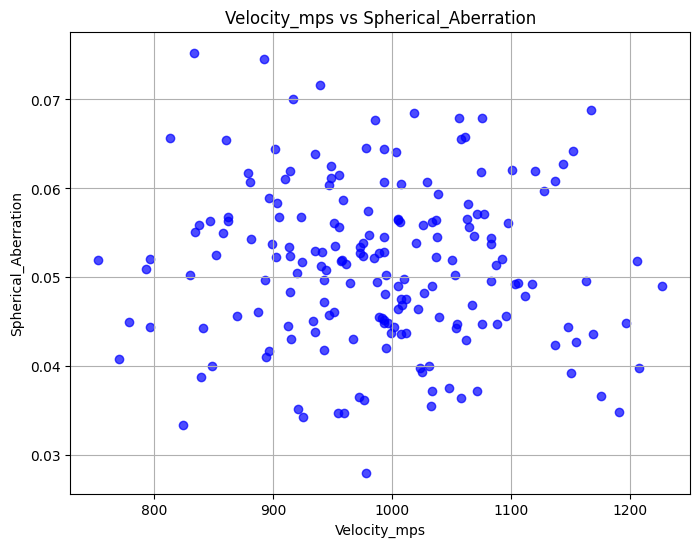

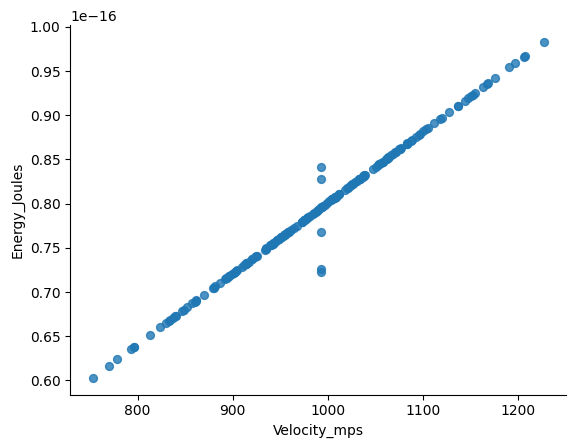

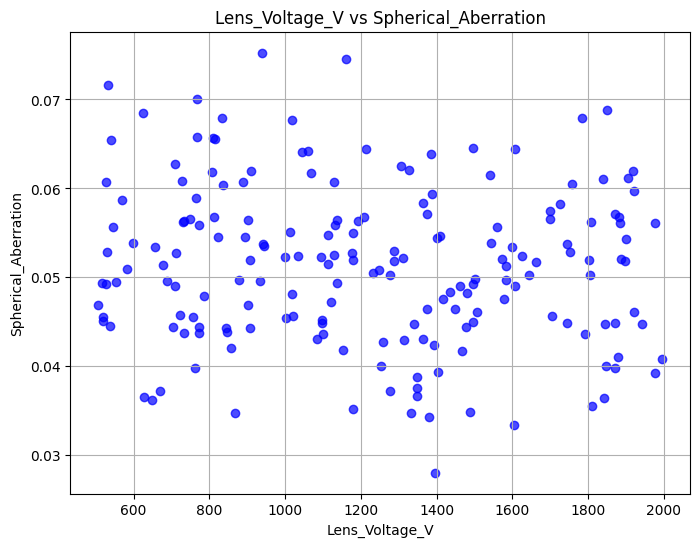

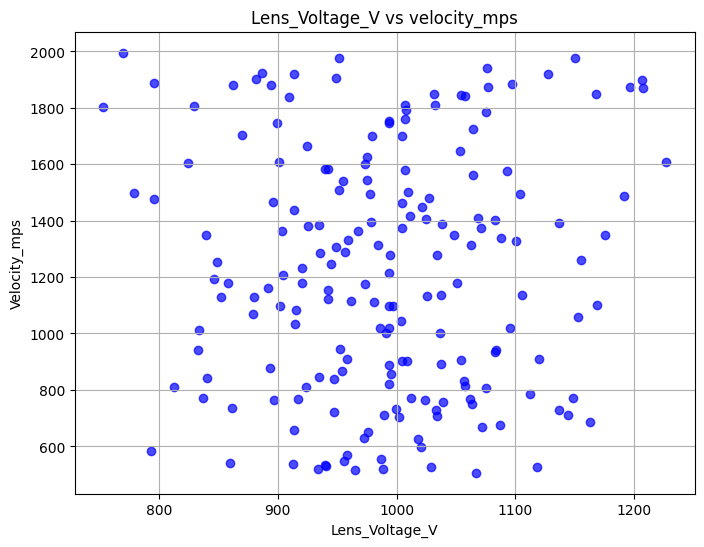

In [73]:
df_sorted = df.apply(lambda col: col.sort_values().values)
print(df_sorted)

# Plot column 4 vs column 7
plt.figure(figsize=(8, 6))
plt.scatter(df.iloc[:, 3], df.iloc[:, 6], color='blue', alpha=0.7)


# Labels
plt.xlabel(df.columns[3])
plt.ylabel(df.columns[6])
plt.title(f"{df.columns[3]} vs {df.columns[6]}")
plt.grid(True)

plt.show()

# @title Velocity_mps vs Energy_Joules

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Velocity_mps', y='Energy_Joules', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)
import matplotlib.pyplot as plt

# Create a scatter plot of 'Lens_Voltage_V' vs 'Spherical_Aberration'
plt.figure(figsize=(8, 6))
plt.scatter(df.iloc[:, 5], df.iloc[:, 6], color='blue', alpha=0.7)

# Labels and title
plt.xlabel('Lens_Voltage_V')
plt.ylabel('Spherical_Aberration')
plt.title('Lens_Voltage_V vs Spherical_Aberration')
plt.grid(True)

plt.show()

# Create a line plot of 'Lens_Voltage_V' vs 'Velocity_mps'vs
plt.figure(figsize=(8, 6))
plt.scatter(df.iloc[:, 3], df.iloc[:, 5], color='blue', alpha=0.7)

# Labels and title
plt.xlabel('Lens_Voltage_V')
plt.ylabel('Velocity_mps')
plt.title('Lens_Voltage_V vs velocity_mps')
plt.grid(True)






In [ ]:
df = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]
print(df)
print("Remaining rows:", len(df))
print("Missing outliers:", df[((df < lower_bound) | (df > upper_bound)).any(axis=1)].shape[0])



     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1    0.745071    0.536681    840.557234   6.732863e-17   
1              2   -0.207396    0.841177    940.062498   7.529901e-17   
3              4    2.284545    1.580703   1004.698059   8.047631e-17   
4              5   -0.351230   -2.066504    954.993453   7.649498e-17   
5              6   -0.351205   -1.406738   1062.284993   8.508903e-17   
..           ...         ...         ...           ...            ...   
195          196    0.577976   -0.703763    948.998360   7.601477e-17   
196          197   -1.325786   -2.569702    973.012506   7.793830e-17   
197          198    0.230588    2.030809    993.392020   7.226010e-17   
198          199    0.087313   -0.171810    955.570674   7.654121e-17   
199          200   -1.714455    1.856724   1037.730049   8.312218e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        843.877093              0.044244           2.726625

In [ ]:
print(df)

     Particle_ID  Position_X  Position_Y  Velocity_mps  Energy_Joules  \
0              1    0.745071    0.536681    840.557234   6.732863e-17   
1              2   -0.207396    0.841177    940.062498   7.529901e-17   
3              4    2.284545    1.580703   1004.698059   8.047631e-17   
4              5   -0.351230   -2.066504    954.993453   7.649498e-17   
5              6   -0.351205   -1.406738   1062.284993   8.508903e-17   
..           ...         ...         ...           ...            ...   
195          196    0.577976   -0.703763    948.998360   7.601477e-17   
196          197   -1.325786   -2.569702    973.012506   7.793830e-17   
197          198    0.230588    2.030809    993.392020   7.226010e-17   
198          199    0.087313   -0.171810    955.570674   7.654121e-17   
199          200   -1.714455    1.856724   1037.730049   8.312218e-17   

     Lens_Voltage_V  Spherical_Aberration  Trajectory_Spread  
0        843.877093              0.044244           2.726625

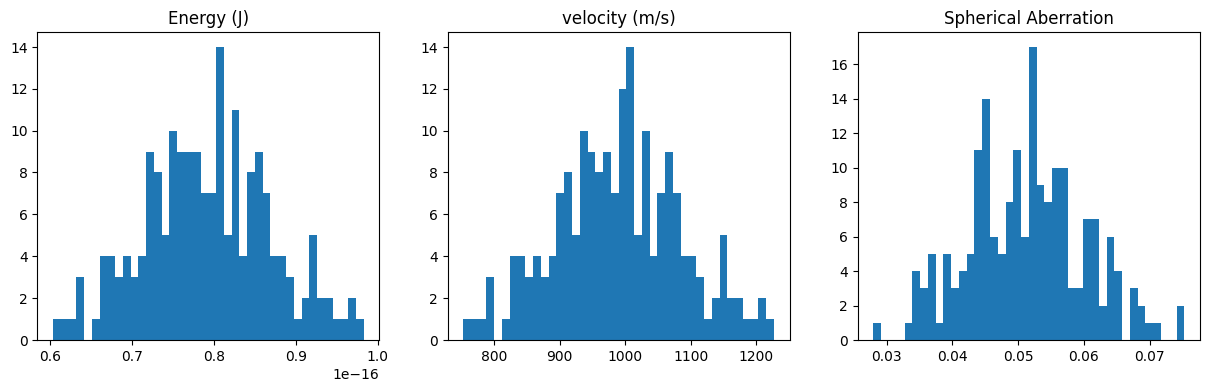

In [64]:
# histograms
fig, axs = plt.subplots(1,3, figsize=(15,4))
axs[0].hist(df['Energy_Joules'], bins=40); axs[0].set_title('Energy (J)')
axs[1].hist(df['Velocity_mps'], bins=40); axs[1].set_title('velocity (m/s)')
axs[2].hist(df['Spherical_Aberration'], bins=40); axs[2].set_title('Spherical Aberration')
plt.show()


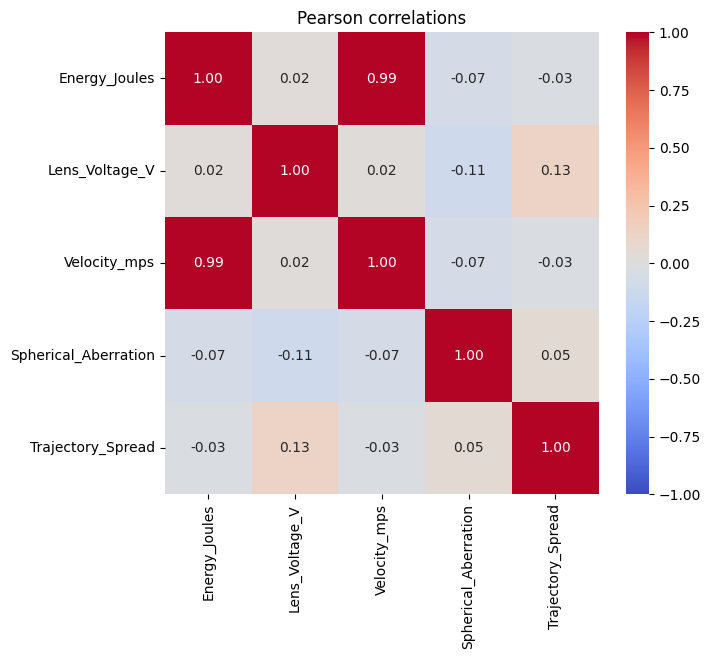

In [ ]:
cols = ['Energy_Joules','Lens_Voltage_V','Velocity_mps','Spherical_Aberration','Trajectory_Spread']
corr = df[cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson correlations')
plt.show()

In [ ]:
# Define X (input features) and y (target variable)
X = df.drop(columns=["Spherical_Aberration"])
y = df["Spherical_Aberration"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(comparison.head())


       Actual  Predicted
195  0.061173   0.050044
173  0.028012   0.051579
21   0.036647   0.050018
18   0.049256   0.052184
71   0.040813   0.052015


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 8.91750075120024e-05
R² Score: -0.1286794155804638


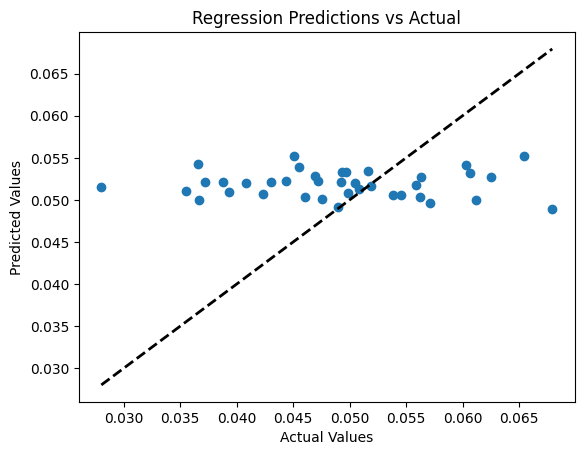

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Regression Predictions vs Actual")

# Add a line representing the ideal prediction (actual == predicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 8.91750075120024e-05
R² Score: -0.1286794155804638
